# Install and import packages

In [1]:
!pip install --upgrade seaborn
!pip install plotly

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Utils and Global variables

In [3]:
# Load original dataset
data_original = pd.read_csv('./datasets/vehicle_2_47174e+18.csv')

In [4]:
# Load synthetic dataset
epoch = 1200
synthetic_data = pd.read_csv(f'./Generated_data/epoch_{epoch}/EV_generated_data_{epoch}.csv')

In [5]:
# Set SAVE equals to True, in order to Save cleaned data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin1/windows_size_20/'
    
    file_trip_path_csv = os.path.join(output_dir, f'EV_generated_data__trip_cleaned.csv')
    file_charge_path_csv = os.path.join(output_dir, f'EV_generated_data__charge_cleaned.csv')
    file_cleaned_path_csv = os.path.join(output_dir, f'EV_generated_data_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

In [6]:
# Set REASSIGN_CHARGE_MODE to True, in order to have a similar behavior with the original dataset for charge_mode feature
REASSIGN_CHARGE_MODE = True

In [7]:
# ===============================
# Threshold Configuration
# ===============================

# --- Discharge thresholds ---
MAX_DISCHARGE_PER_KM = 0.9    # Maximum allowable battery discharge per km
MIN_DISCHARGE_PER_KM = -1.0   # Minimum (negative) discharge per km

# --- Distance per discharge thresholds ---
MAX_KM_PER_DISCHARGE = 20     # Max km possible per discharge unit
MIN_KM_PER_DISCHARGE = -10    # Min km per discharge unit (negative edge case)

# --- Charging thresholds ---
MAX_CHARGE_PER_MIN = 1.10     # Maximum acceptable charge per minute
MIN_CHARGE_PER_MIN = 0.005    # Minimum acceptable charge per minute


# --- Speed threshold ---
SPEED_THRESHOLD = 130         # Max speed before flagging over-speed conditions


# Original dataset

## Trip data original

In [8]:
#trip_ data
trip_data_original = data_original[data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          1207 non-null   float64
 1   timestamp    1207 non-null   object 
 2   end_time     1207 non-null   object 
 3   odo          1207 non-null   float64
 4   end_odo      1207 non-null   float64
 5   soc          1207 non-null   float64
 6   end_soc      1207 non-null   float64
 7   event        1207 non-null   object 
 8   charge_mode  1207 non-null   object 
dtypes: float64(5), object(4)
memory usage: 85.0+ KB


In [9]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\nStatistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 1134
Statistics on driven km:
 count    1134.000000
mean       41.036223
std        46.765638
min         0.000000
25%         8.171871
50%        20.304685
75%        64.996092
max       378.187500
Name: km_driven, dtype: float64

Statistics on discharge:
 count    1134.000000
mean        7.874339
std         9.234552
min        -0.400000
25%         1.200000
50%         3.600000
75%        12.900000
max        74.600000
Name: discharge, dtype: float64


In [10]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

In [11]:
anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 7


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
16,-2.471740e+18,2021-04-29 19:05:00,2021-04-29 19:16:00,2419.812500,2419.84375,25.8,25.4,trip,0,0.031250,0.4,0.078125,12.800000
33,-2.471740e+18,2021-05-02 16:11:00,2021-05-02 16:53:00,2609.625000,2609.65625,34.1,33.3,trip,0,0.031250,0.8,0.039062,25.600000
55,-2.471740e+18,2021-05-05 17:40:00,2021-05-05 18:48:00,2875.703125,2875.75000,39.6,38.8,trip,0,0.046875,0.8,0.058594,17.066667
269,-2.471740e+18,2021-06-08 18:54:00,2021-06-08 18:56:00,11825.156250,11825.65625,50.5,49.8,trip,0,0.500000,0.7,0.714286,1.400000
446,-2.471740e+18,2021-07-11 19:53:00,2021-07-11 20:06:00,21003.656250,21009.34375,62.0,54.0,trip,0,5.687500,8.0,0.710938,1.406593
512,-2.471740e+18,2021-07-17 23:55:00,2021-07-18 01:05:00,23272.312500,23272.64063,41.9,39.2,trip,0,0.328130,2.7,0.121530,8.228446
788,-2.471740e+18,2021-08-10 15:06:00,2021-08-10 15:08:00,31879.125000,31879.32813,36.0,35.6,trip,0,0.203130,0.4,0.507825,1.969182


In [12]:
anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] < MIN_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [13]:
# Identify anomalous records with high km per percentage of battery discharge 
anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))

Number of anomalous discharge records: 3


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
535,-2.471740e+18,2021-07-23 00:31:00,2021-07-23 01:14:00,25236.45313,25248.85123,60.0,59.6,trip,0,12.3981,0.4,30.99525,0.032263
596,-2.471740e+18,2021-07-29 20:46:00,2021-07-29 21:00:00,27163.21875,27172.03125,15.2,14.9,trip,0,8.8125,0.3,29.37500,0.034043
521,-2.471740e+18,2021-07-13 00:08:00,2021-07-13 00:21:00,21541.39063,21550.70313,47.8,47.4,trip,0,9.3125,0.4,23.28125,0.042953


In [14]:
# Identify anomalous records with low km per percentage of battery discharge 
anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


trip_data_original = trip_data_original[~(trip_data_original['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE)].reset_index(drop=True)
anomalous_discharge_records.head(len(anomalous_discharge_records))

Number of anomalous discharge records: 0


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km


In [15]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     1124 non-null   float64
 1   timestamp               1124 non-null   object 
 2   end_time                1124 non-null   object 
 3   odo                     1124 non-null   float64
 4   end_odo                 1124 non-null   float64
 5   soc                     1124 non-null   float64
 6   end_soc                 1124 non-null   float64
 7   event                   1124 non-null   object 
 8   charge_mode             1124 non-null   object 
 9   km_driven               1124 non-null   float64
 10  discharge               1124 non-null   float64
 11  km_per_perc_of_battery  1124 non-null   float64
 12  discharge_per_km        1124 non-null   float64
dtypes: float64(9), object(4)
memory usage: 114.3+ KB


In [16]:
trip_data_original['discharge_per_km'].describe()

count    1124.000000
mean        0.171832
std         0.081194
min        -0.474074
25%         0.151802
50%         0.182523
75%         0.205293
max         0.752941
Name: discharge_per_km, dtype: float64

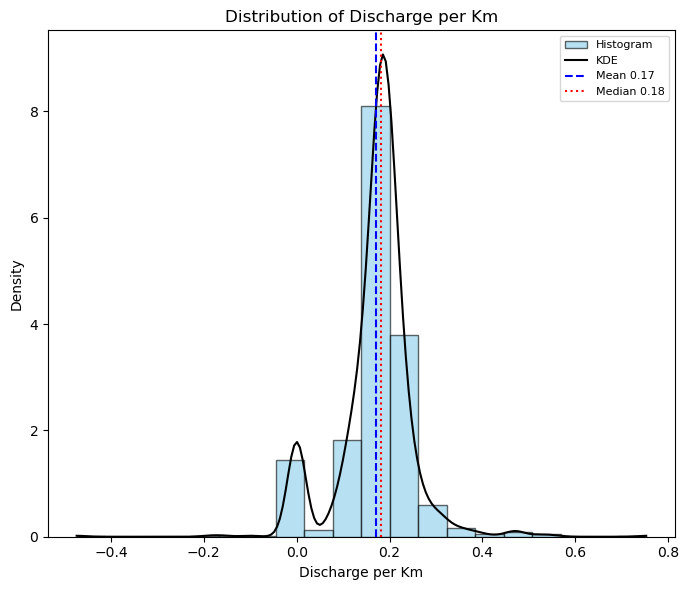

In [17]:
# Function that plot histogram and density of feature values provided
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20, density=True):
    """Plots histogram + KDE + mean & median, using DENSITY (not frequency)."""
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    # Histogram as DENSITY
    counts, bin_edges, _ = ax.hist(
        y, bins=bins, density=density, alpha=0.6,
        color=color, edgecolor='black', label='Histogram'
    )

    # KDE on density scale
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        kde_vals = kde(x_grid)
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass

    # Mean & median lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'Mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'Median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data_original.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='skyblue', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

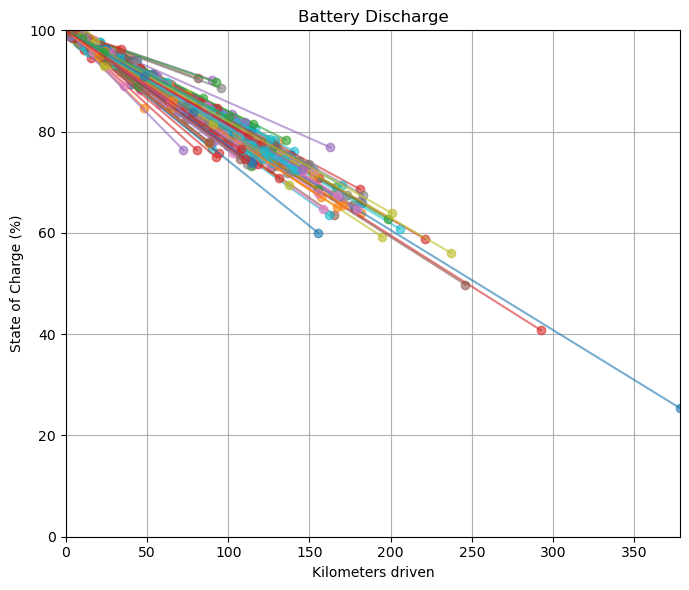

In [18]:
#visualize delta_soc
trip_data_original['delta_soc'] = trip_data_original['end_soc'] - trip_data_original['soc']
trip_data_original['soc'] = 100
trip_data_original['end_soc'] = trip_data_original['soc'] + trip_data_original['delta_soc'] 



# Max km for x-axis scaling
max_km_driven = trip_data_original['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data_original.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data_original.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


## Charge data original

In [19]:
charge_data_original = data_original[data_original['event'] == 'charge'].reset_index(drop=True)
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          543 non-null    float64
 1   timestamp    543 non-null    object 
 2   end_time     543 non-null    object 
 3   odo          543 non-null    float64
 4   end_odo      543 non-null    float64
 5   soc          543 non-null    float64
 6   end_soc      543 non-null    float64
 7   event        543 non-null    object 
 8   charge_mode  543 non-null    object 
dtypes: float64(5), object(4)
memory usage: 38.3+ KB


In [20]:
# Count number of entries for each charge_mode
counts = charge_data_original['charge_mode'].value_counts()
print(counts)

charge_mode
120           249
DCCharging    214
240            72
0               8
Name: count, dtype: int64


In [21]:
# Remove duplicates
charge_data_original = charge_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(charge_data_original)}")

charge_data_original['charge'] = charge_data_original['end_soc'] - charge_data_original['soc']
charge_data_original['discharge'] = charge_data_original['soc'] - charge_data_original['end_soc']

# Convert timestamps to datetime
charge_data_original['timestamp'] = pd.to_datetime(charge_data_original['timestamp'], errors='coerce')
charge_data_original['end_time'] = pd.to_datetime(charge_data_original['end_time'], errors='coerce')

# Compute event duration in minutes
charge_data_original['duration_minutes'] = (charge_data_original['end_time'] - charge_data_original['timestamp']).dt.total_seconds() / 60

print("\nStatistics on Charge:\n", charge_data_original['charge'].describe())

Number of rows after removing duplicates: 516

Statistics on Charge:
 count    516.000000
mean      17.133527
std       13.898268
min        0.300000
25%        3.175000
50%       13.950000
75%       29.400000
max       65.100000
Name: charge, dtype: float64


In [22]:
charge_data_original['min_per_perc_of_battery'] = charge_data_original.apply(
    lambda row: row['duration_minutes'] / -row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

charge_data_original['charge_per_min'] = charge_data_original.apply(
    lambda row: -row['discharge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

In [23]:
anomalous_rows_charge = charge_data_original[(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)]
print(f"Number of anamalous rows: {anomalous_rows_charge.shape[0]}")

charge_data_original = charge_data_original[~(charge_data_original['charge_per_min'] > MAX_CHARGE_PER_MIN)].reset_index(drop=True)
anomalous_rows_charge.head(len(anomalous_rows_charge ))

Number of anamalous rows: 12


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,charge,discharge,duration_minutes,min_per_perc_of_battery,charge_per_min
0,-2.471740e+18,2021-04-29 10:46:00,2021-04-29 11:17:00,2286.71875,2286.734375,24.3,59.2,charge,DCCharging,34.9,-34.9,31.0,0.888252,1.125806
112,-2.471740e+18,2021-06-07 22:55:00,2021-06-07 23:26:00,11661.75000,11661.750000,29.8,65.0,charge,DCCharging,35.2,-35.2,31.0,0.880682,1.135484
155,-2.471740e+18,2021-06-19 00:21:00,2021-06-19 00:51:00,15289.43750,15289.437500,29.8,64.3,charge,DCCharging,34.5,-34.5,30.0,0.869565,1.150000
223,-2.471740e+18,2021-07-15 20:12:00,2021-07-15 20:27:00,22365.68750,22365.687500,28.2,44.7,charge,DCCharging,16.5,-16.5,15.0,0.909091,1.100000
387,-2.471740e+18,2021-08-17 19:52:00,2021-08-17 20:09:00,34609.67188,34609.671880,29.8,50.9,charge,DCCharging,21.1,-21.1,17.0,0.805687,1.241176
390,-2.471740e+18,2021-08-18 13:57:00,2021-08-18 14:28:00,34909.48438,34909.484380,37.2,72.5,charge,DCCharging,35.3,-35.3,31.0,0.878187,1.138710
391,-2.471740e+18,2021-08-18 21:29:00,2021-08-18 22:04:00,35093.70313,35093.703130,37.2,76.8,charge,DCCharging,39.6,-39.6,35.0,0.883838,1.131429
394,-2.471740e+18,2021-08-19 15:57:00,2021-08-19 16:15:00,35501.14063,35501.140630,43.1,63.1,charge,DCCharging,20.0,-20.0,18.0,0.900000,1.111111
413,-2.471740e+18,2021-08-25 16:29:00,2021-08-25 16:41:00,37669.50000,37669.500000,30.9,48.6,charge,DCCharging,17.7,-17.7,12.0,0.677966,1.475000
453,-2.471740e+18,2021-09-07 01:55:00,2021-09-07 02:40:00,41677.68750,41677.687500,27.4,81.1,charge,DCCharging,53.7,-53.7,45.0,0.837989,1.193333


In [24]:
charge_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   vin                      504 non-null    float64       
 1   timestamp                504 non-null    datetime64[ns]
 2   end_time                 504 non-null    datetime64[ns]
 3   odo                      504 non-null    float64       
 4   end_odo                  504 non-null    float64       
 5   soc                      504 non-null    float64       
 6   end_soc                  504 non-null    float64       
 7   event                    504 non-null    object        
 8   charge_mode              504 non-null    object        
 9   charge                   504 non-null    float64       
 10  discharge                504 non-null    float64       
 11  duration_minutes         504 non-null    float64       
 12  min_per_perc_of_battery  504 non-nul

In [25]:
charge_data_original['charge_per_min'].describe()

count    504.000000
mean       0.379533
std        0.440543
min        0.006557
25%        0.019343
50%        0.072727
75%        0.909677
max        1.100000
Name: charge_per_min, dtype: float64

In [26]:
# Print max charge_data_original['charge_per_min'] 
max_charge_mode_per_minute = charge_data_original.groupby("charge_mode")["charge_per_min"].max()
print(max_charge_mode_per_minute)

charge_mode
0             1.006667
120           0.040000
240           0.158333
DCCharging    1.100000
Name: charge_per_min, dtype: float64


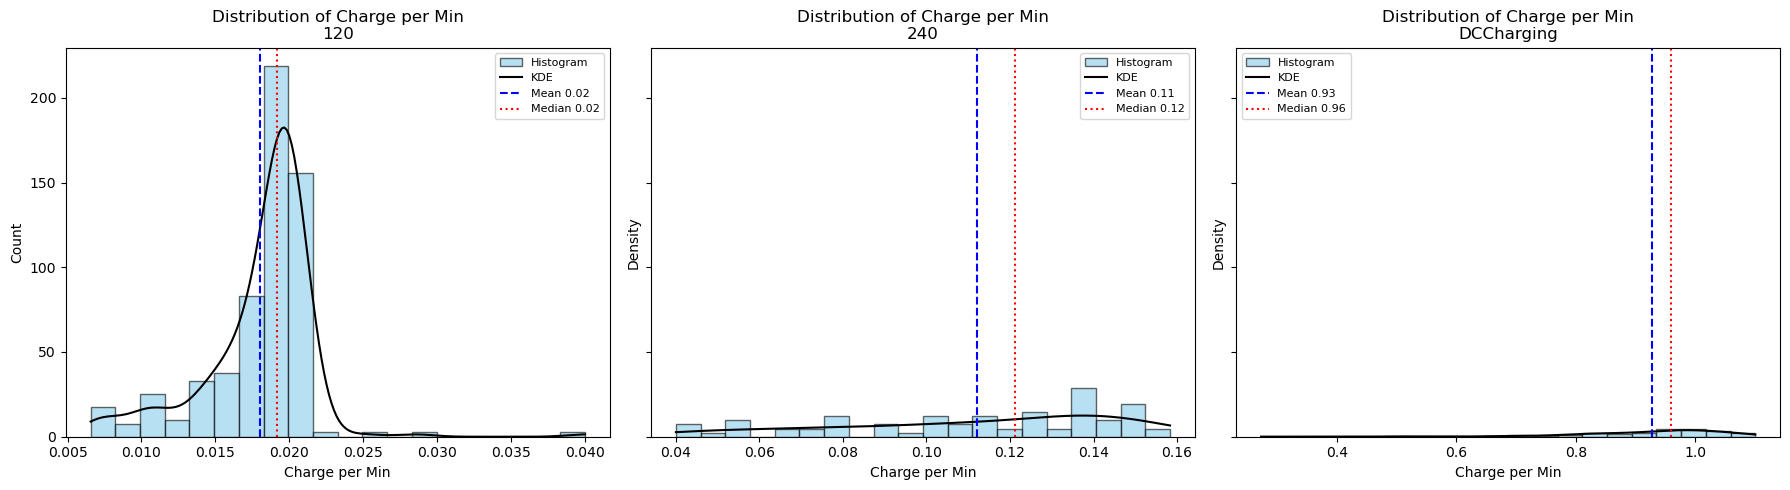

In [27]:
# --- Distribution of Charge per min ---

# Create a figure with 3 subplots, one for each charge_mode
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, mode in enumerate(['120', '240', 'DCCharging']):
    data_mode = charge_data_original.loc[charge_data_original['charge_mode'] == mode, 'charge_per_min']
    ax = axes[i]
    plot_hist_with_kde(data_mode, ax,
                       color='skyblue',
                       title=f"Distribution of Charge per Min\n{mode}",
                       xlabel='Charge per Min')

axes[0].set_ylabel('Count')  # common y-axis label
plt.tight_layout()
plt.show()

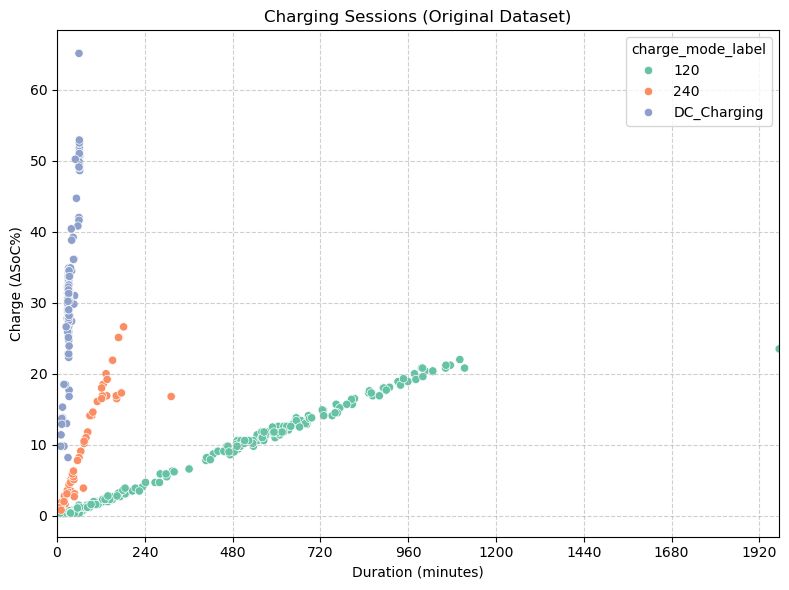

In [28]:
"""
Scatterplot of duration vs. charge,
colored by charge_mode (mapped to labels).
"""
import matplotlib.ticker as mticker

# Mapping of charge_mode
charge_mode_map = {
    '120': "120",
    '240': "240",
    'DCCharging': "DC_Charging"
}

charge_data_original = charge_data_original.copy()
charge_data_original["charge_mode_label"] = charge_data_original["charge_mode"].map(charge_mode_map)

# Define consistent color palette (matching Set2)
fixed_palette = {
    "120": "#66c2a5",       # greenish
    "240": "#fc8d62",       # orange
    "DC_Charging": "#8da0cb" # blue
}

# Define desired order for hues
hue_order = ["120", "240", "DC_Charging"]

# Compute derived features
max_duration = charge_data_original["duration_minutes"].max()
charge_data_original['charge'] = -charge_data_original['discharge']

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=charge_data_original,
    x="duration_minutes",
    y="charge",
    hue="charge_mode_label",
    hue_order=hue_order,     # ← Force order
    palette=fixed_palette,   # ← Consistent colors
    legend="auto"
)

plt.title("Charging Sessions (Original Dataset)")
plt.xlim(0, max_duration)
plt.xlabel("Duration (minutes)")
plt.ylabel("Charge (ΔSoC%)")
plt.grid(True)

plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(240))
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Post-processing generated data event-level

## Post-process trip data

### Data Inspection and Cleaning

In [29]:
##### Load trip data
trip_data = synthetic_data.copy()

# Add a column id to keep the number of the row
trip_data['id'] = trip_data.index
trip_data = trip_data[trip_data['event'] == 0].reset_index(drop=True)
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11571 entries, 0 to 11570
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             11571 non-null  int64  
 1   charge_mode       11571 non-null  int64  
 2   duration_b_e      11571 non-null  float64
 3   duration_minutes  11571 non-null  float64
 4   km_driven         11571 non-null  float64
 5   charge            11571 non-null  float64
 6   id                11571 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 632.9 KB


In [30]:
trip_data.head(10)

,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id
0,0,0,52.999690,27.335241,4.871357,3.529539,2
1,0,0,119.353380,73.254649,42.761093,-10.542687,3
2,0,0,52.203247,22.137493,3.252840,6.382382,5
3,0,0,33.903074,11.885446,7.414533,0.809159,6
4,0,0,39.694154,11.035475,7.483603,7.507662,7
5,0,0,57.754345,23.964151,9.700326,-1.192829,8
6,0,0,71.148374,77.784270,48.037490,-8.358526,9
7,0,0,57.355374,33.841657,26.122317,-5.162487,12
8,0,0,32.175199,11.452314,8.878279,-0.397273,13
9,0,0,52.081756,18.425071,5.978888,1.210126,14


### Data description

In [31]:
# Remove duplicates
init_len = len(trip_data)
trip_data = trip_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(trip_data)}")

Number of duplicates removed: 0


In [32]:
# Check for missing values and print records with them
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

records_with_nan = trip_data[trip_data.isna().any(axis=1)]

length = len(records_with_nan)
print(f"\nNumber of records with missing values: {length}\n")
records_with_nan.head(length)

| Features | NaN-counter |
event               0
charge_mode         0
duration_b_e        0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|

Number of records with missing values: 0



,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id


In [33]:
# main statistics of the dataset
trip_data['delta_soc'] = trip_data['charge']
print("Statistics of the dataset:")
trip_data[['km_driven', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
km_driven,11571.0,33.198210,31.697471,2.453427,11.112059,19.869071,44.152935,196.299440
delta_soc,11571.0,-5.254764,7.932393,-33.288980,-9.279585,-3.338554,-0.907050,24.170709


In [34]:
# Add discharge
trip_data['discharge'] = - trip_data['charge']


# Add avg_speed in km/h 
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['km_driven']) / (trip_data['duration_minutes'] / 60),
    0
)

# Add km_per_perc_of_battery and discharge_per_km 
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)
trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

# Print statistics
print('Statistics before post-processing\n')
print("Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\nStatistics on discharge:\n", trip_data['discharge'].describe())
print("\nStatistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\nStatistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\nStatistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics before post-processing

Statistics on driven km:
 count    11571.000000
mean        33.198210
std         31.697471
min          2.453427
25%         11.112059
50%         19.869071
75%         44.152935
max        196.299440
Name: km_driven, dtype: float64

Statistics on discharge:
 count    11571.000000
mean         5.254764
std          7.932393
min        -24.170709
25%          0.907050
50%          3.338554
75%          9.279585
max         33.288980
Name: discharge, dtype: float64

Statistics on average speed:
 count    11571.000000
mean        33.698079
std         11.501637
min          4.608700
25%         27.892310
50%         36.491418
75%         41.923109
max         77.822905
Name: avg_speed, dtype: float64
99th percentile of average speed: 54.82 km/h

Statistics on km per percentage of battery:
 count    11571.000000
mean         7.263713
std        292.136878
min      -2588.609595
25%          4.233752
50%          5.095193
75%          6.503563
max      295

### Identify and remove anomalous records

In [35]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
snapshot_records.head(length)

Number of snapshot records: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [36]:
# Remove snapshot records
trip_data = trip_data.drop(snapshot_records.index).reset_index(drop=True)

In [37]:
# Identify records with negative duration
negative_duration_records = trip_data[(trip_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
negative_duration_records.head(length)

Number of records with negative duration: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [38]:
# Remove records with negative duration
trip_data = trip_data.drop(negative_duration_records.index).reset_index(drop=True)

In [39]:
# Identify stationary records (data with no changes in soc, odo, but positive duration)
stationary_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary records: {length}")
stationary_records.head(length)

Number of stationary records: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [40]:
# Remove stationary records
trip_data = trip_data.drop(stationary_records.index).reset_index(drop=True)

In [41]:
# Identify records with (end_soc) [%] > (soc + 1) [%]   
anomalous_soc_records = trip_data[(trip_data['charge'] > 1)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 1634


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,0,0,52.999690,27.335241,4.871357,3.529539,2,3.529539,-3.529539,10.692476,-1.380168,-0.724550
2,0,0,52.203247,22.137493,3.252840,6.382382,5,6.382382,-6.382382,8.816282,-0.509659,-1.962095
4,0,0,39.694154,11.035475,7.483603,7.507662,7,7.507662,-7.507662,40.688436,-0.996796,-1.003215
9,0,0,52.081756,18.425071,5.978888,1.210126,14,1.210126,-1.210126,19.469845,-4.940714,-0.202400
15,0,0,41.885495,26.229443,8.086179,4.187479,21,4.187479,-4.187479,18.497181,-1.931037,-0.517856
...,...,...,...,...,...,...,...,...,...,...,...,...
11513,0,0,25.982148,17.112656,12.301223,5.309545,17334,5.309545,-5.309545,43.130265,-2.316813,-0.431627
11518,0,1,59.779198,24.732490,5.570701,11.127933,17341,11.127933,-11.127933,13.514291,-0.500605,-1.997582
11528,0,0,48.961982,26.795492,3.493245,8.227111,17357,8.227111,-8.227111,7.822014,-0.424602,-2.355148
11540,0,0,60.941614,18.919414,5.881237,2.663730,17372,2.663730,-2.663730,18.651434,-2.207895,-0.452920


In [42]:
# Remove anomalous soc records
trip_data = trip_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [43]:
# Identify anomalous movement records (end_odo < odo)
anomalous_movement_records = trip_data[(trip_data['km_driven'] < 0)]

length = anomalous_movement_records.shape[0]
print(f"Number of anomalous movement records: {length}")
anomalous_movement_records.head(length)

Number of anomalous movement records: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [44]:
# Remove anomalous movement records
trip_data = trip_data.drop(anomalous_movement_records.index).reset_index(drop=True)

In [45]:
# Identify records with high average speed 
anomalous_speed_records = trip_data[(trip_data['avg_speed'] > SPEED_THRESHOLD)]
length = anomalous_speed_records.shape[0]
print(f"Number of records with avg_speed > {SPEED_THRESHOLD} km/h: {length}")
anomalous_speed_records.head(length)

Number of records with avg_speed > 130 km/h: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [46]:
# Remove anomalous speed records
trip_data = trip_data.drop(anomalous_speed_records.index).reset_index(drop=True)

In [47]:
# Identify anomalous records with high discharge per km
anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [48]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [49]:
# Identify anomalous records with low discharge per km
anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] < MIN_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [50]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [51]:
# Identify anomalous records with high km per percentage of battery discharge 
anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 381


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
6443,0,0,30.981286,9.829248,8.194386,-0.000278,11253,-0.000278,0.000278,50.020427,29502.536742,0.000034
9675,0,0,23.427833,37.405793,16.584318,-0.001951,17000,-0.001951,0.001951,26.601738,8498.535546,0.000118
7805,0,0,63.086458,21.431157,7.480700,-0.001876,13652,-0.001876,0.001876,20.943434,3986.535641,0.000251
1838,0,0,37.351324,14.089616,9.641842,-0.009629,3216,-0.009629,0.009629,41.059356,1001.363536,0.000999
741,0,0,31.368258,10.666470,8.634455,-0.013576,1345,-0.013576,0.013576,48.569709,636.027443,0.001572
...,...,...,...,...,...,...,...,...,...,...,...,...
8499,0,0,39.971634,12.757618,8.661963,-0.427941,14883,-0.427941,0.427941,40.737838,20.241041,0.049405
1735,0,0,36.679373,47.425013,14.580378,-0.724673,3029,-0.724673,0.724673,18.446441,20.119932,0.049702
4692,0,0,27.038071,30.374222,17.039622,-0.849708,8209,-0.849708,0.849708,33.659374,20.053500,0.049867
965,0,0,76.558482,29.783849,8.021274,-0.400704,1726,-0.400704,0.400704,16.158975,20.017967,0.049955


In [52]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [53]:
# Identify anomalous records with low km per percentage of battery discharge 
anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")
anomalous_discharge_records.head(length)

Number of anomalous discharge records: 408


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
7255,0,0,33.478605,11.657277,8.571164,0.849885,13183,0.849885,-0.849885,44.115780,-10.085083,-0.099156
2466,0,0,26.162135,12.037882,9.997755,0.977851,4468,0.977851,-0.977851,49.831464,-10.224209,-0.097807
7035,0,0,26.361620,17.110317,7.527893,0.728356,12794,0.728356,-0.728356,26.397732,-10.335456,-0.096754
385,0,0,58.352802,20.254595,6.613407,0.639068,712,0.639068,-0.639068,19.590834,-10.348514,-0.096632
8261,0,0,40.451599,21.671968,7.353857,0.703459,15048,0.703459,-0.703459,20.359545,-10.453851,-0.095659
...,...,...,...,...,...,...,...,...,...,...,...,...
3416,0,0,51.556794,44.497058,7.260593,0.007008,6227,0.007008,-0.007008,9.790211,-1036.018284,-0.000965
2809,0,0,5.649622,29.207477,15.833660,0.010497,5099,0.010497,-0.010497,32.526590,-1508.386113,-0.000663
5976,0,0,25.904154,14.416707,8.078257,0.005126,10845,0.005126,-0.005126,33.620397,-1575.839084,-0.000635
1293,0,0,41.844998,20.485342,11.410004,0.004843,2381,0.004843,-0.004843,33.419029,-2355.875904,-0.000424


In [54]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [55]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9148 entries, 0 to 9147
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   9148 non-null   int64  
 1   charge_mode             9148 non-null   int64  
 2   duration_b_e            9148 non-null   float64
 3   duration_minutes        9148 non-null   float64
 4   km_driven               9148 non-null   float64
 5   charge                  9148 non-null   float64
 6   id                      9148 non-null   int64  
 7   delta_soc               9148 non-null   float64
 8   discharge               9148 non-null   float64
 9   avg_speed               9148 non-null   float64
 10  km_per_perc_of_battery  9148 non-null   float64
 11  discharge_per_km        9148 non-null   float64
dtypes: float64(9), int64(3)
memory usage: 857.8 KB


In [56]:
# Print statistics
print('Statistics after post-processing\n')
print("Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\nStatistics on discharge:\n", trip_data['discharge'].describe())
print("\nStatistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\nStatistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\nStatistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics after post-processing

Statistics on driven km:
 count    9148.000000
mean       39.530400
std        32.791081
min         4.795057
25%        15.202060
50%        26.594550
75%        54.489102
max       196.299440
Name: km_driven, dtype: float64

Statistics on discharge:
 count    9148.000000
mean        7.653730
std         6.835232
min        -0.994904
25%         2.249417
50%         5.141121
75%        11.443630
max        33.288980
Name: discharge, dtype: float64

Statistics on average speed:
 count    9148.000000
mean       35.076933
std         9.849977
min         4.608700
25%        31.200989
50%        37.463717
75%        42.097582
max        59.377453
Name: avg_speed, dtype: float64
99th percentile of average speed: 50.06 km/h

Statistics on km per percentage of battery:
 count    9148.000000
mean        6.147738
std         2.816905
min        -9.959305
25%         4.733151
50%         5.357093
75%         6.763599
max        19.978098
Name: km_per_perc_of_ba

### Data Visualization and Comparative Analysis

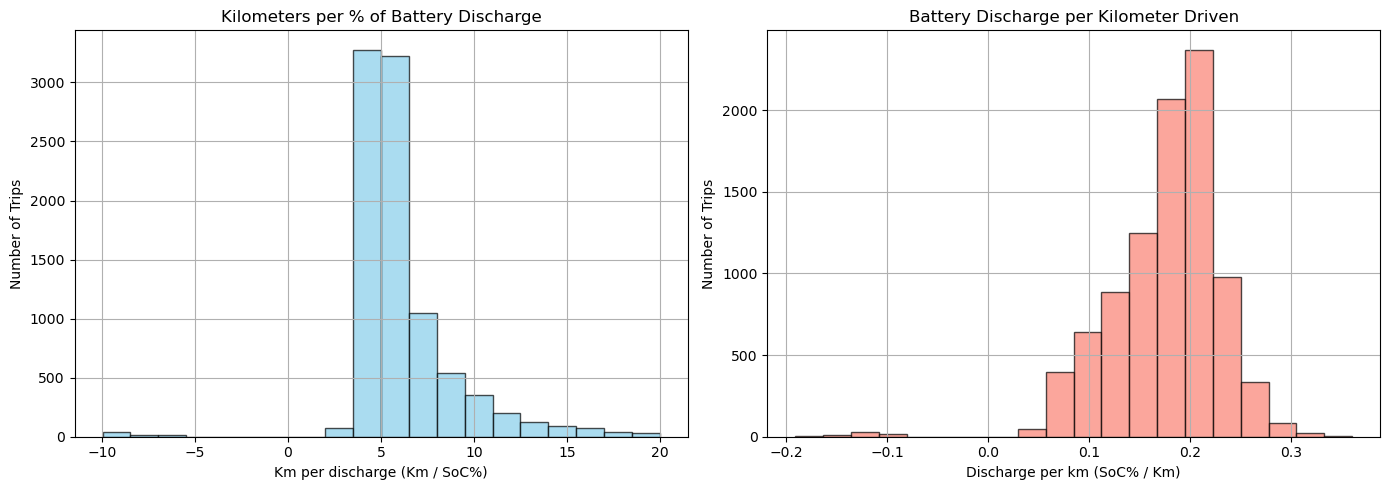

In [57]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [58]:
trip_data.head()

,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,0,0,119.353380,73.254649,42.761093,-10.542687,3,-10.542687,10.542687,35.023928,4.055996,0.246549
1,0,0,33.903074,11.885446,7.414533,0.809159,6,0.809159,-0.809159,37.429977,-9.163257,-0.109132
2,0,0,57.754345,23.964151,9.700326,-1.192829,8,-1.192829,1.192829,24.287094,8.132200,0.122968
3,0,0,71.148374,77.784270,48.037490,-8.358526,9,-8.358526,8.358526,37.054399,5.747125,0.174000
4,0,0,57.355374,33.841657,26.122317,-5.162487,12,-5.162487,5.162487,46.313896,5.060025,0.197627


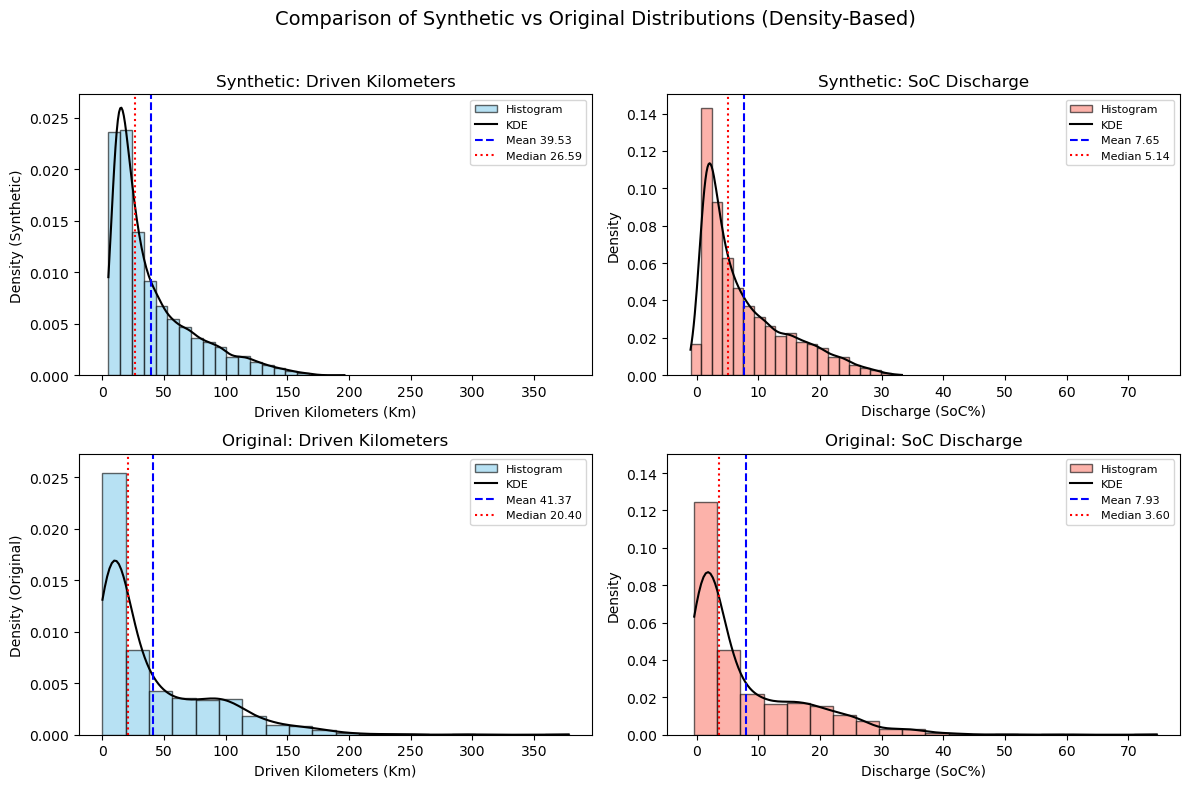

In [59]:
### Visualize comparison between generated and original trip data of main features

# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Discharge', xlabel='Discharge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(trip_data_original.get('km_driven', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data_original.get('discharge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Discharge', xlabel='Discharge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

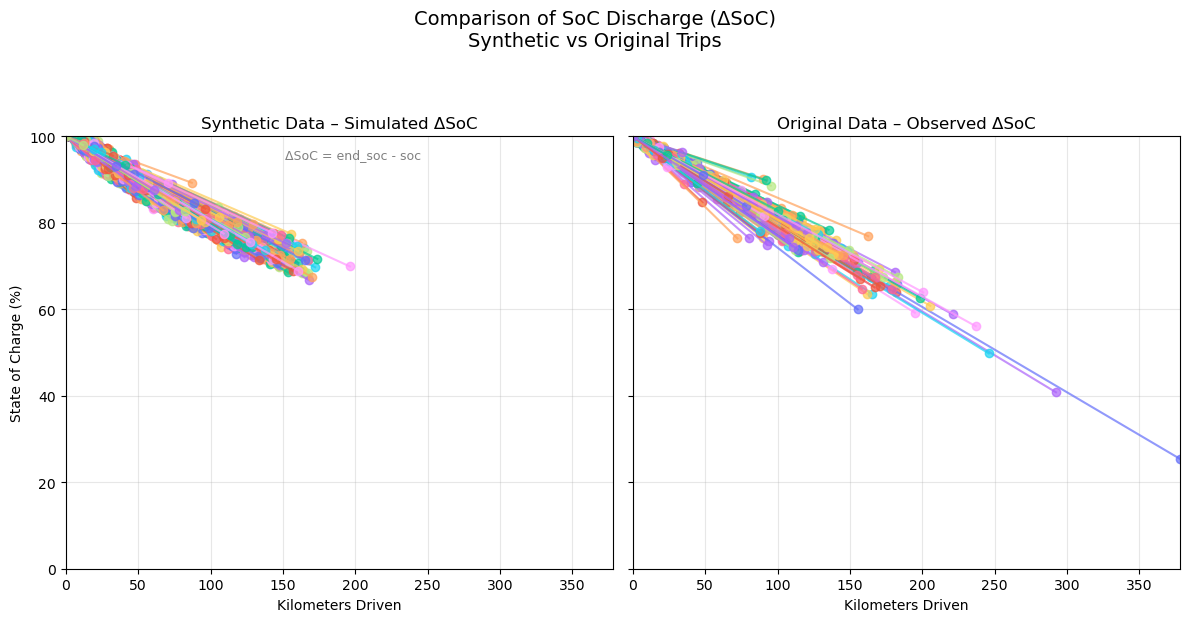

In [60]:
# --- Synthetic data prep ---
trip_data['soc'] = 100
trip_data['end_soc'] = trip_data['soc'] + trip_data['charge']

# --- Shared scales ---
max_km_driven = max(trip_data['km_driven'].max(), trip_data_original['km_driven'].max())

# --- Colors ---
colors = px.colors.qualitative.Plotly

# --- Figure setup ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# ====================================================
# LEFT PANEL – SYNTHETIC
# ====================================================
ax = axes[0]
for i, (_, row) in enumerate(trip_data.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Synthetic Data – Simulated ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.text(max_km_driven * 0.4, 95, "ΔSoC = end_soc - soc", fontsize=9, color='gray')

# ====================================================
# RIGHT PANEL – ORIGINAL
# ====================================================
ax = axes[1]
for i, (_, row) in enumerate(trip_data_original.iterrows()):
    color = colors[i % len(colors)]
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.7, color=color)

ax.set_title('Original Data – Observed ΔSoC', fontsize=12)
ax.set_xlabel('Kilometers Driven')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

# ====================================================
# SHARED SETTINGS
# ====================================================
# Reverse y-axis for intuitive "battery discharge" visualization
for ax in axes:
    ax.invert_yaxis()

fig.suptitle('Comparison of SoC Discharge (ΔSoC)\nSynthetic vs Original Trips', fontsize=14, y=1.03)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [61]:
trip_data['discharge_per_km'].describe()

count    9148.000000
mean        0.176127
std         0.054868
min        -0.190903
25%         0.146338
50%         0.185903
75%         0.210567
max         0.360627
Name: discharge_per_km, dtype: float64

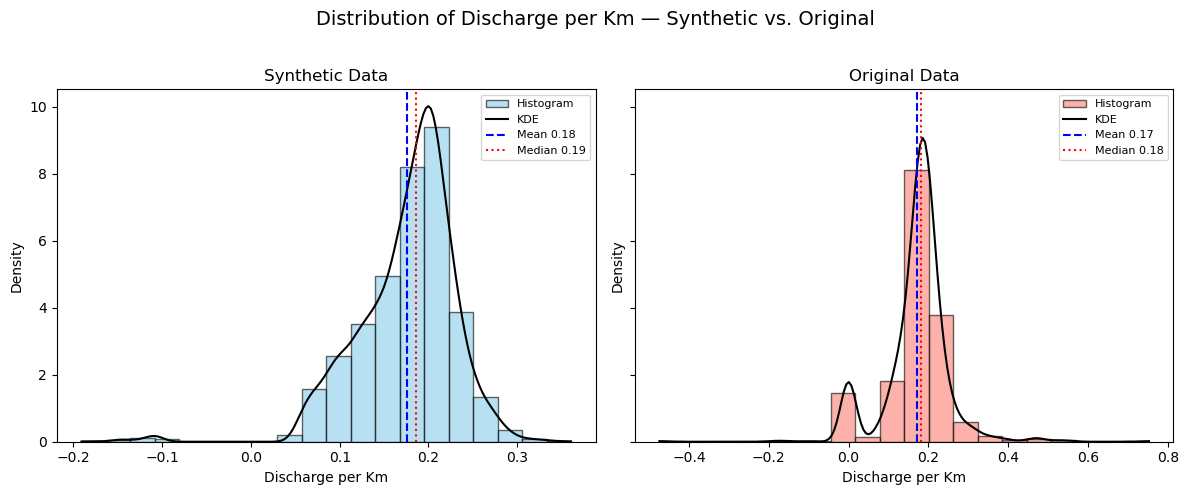

In [62]:
# --- Distribution of Discharge per Km ---
# --- Create side-by-side comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left panel — synthetic data
plot_hist_with_kde(
    trip_data.get('discharge_per_km', pd.Series(dtype=float)),
    axes[0],
    color='skyblue',
    title='Synthetic Data',
    xlabel='Discharge per Km'
)

# Right panel — original data
plot_hist_with_kde(
    trip_data_original.get('discharge_per_km', pd.Series(dtype=float)),
    axes[1],
    color='salmon',
    title='Original Data',
    xlabel='Discharge per Km',
    density=True
)

# --- Styling ---
fig.suptitle('Distribution of Discharge per Km — Synthetic vs. Original', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Save trip data cleaned

In [63]:
# Save DataFrame
if SAVE:
    trip_data.to_csv(file_trip_path_csv, index=False)

In [64]:
trip_data.head()

,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km,soc,end_soc
0,0,0,119.353380,73.254649,42.761093,-10.542687,3,-10.542687,10.542687,35.023928,4.055996,0.246549,100,89.457313
1,0,0,33.903074,11.885446,7.414533,0.809159,6,0.809159,-0.809159,37.429977,-9.163257,-0.109132,100,100.809159
2,0,0,57.754345,23.964151,9.700326,-1.192829,8,-1.192829,1.192829,24.287094,8.132200,0.122968,100,98.807171
3,0,0,71.148374,77.784270,48.037490,-8.358526,9,-8.358526,8.358526,37.054399,5.747125,0.174000,100,91.641474
4,0,0,57.355374,33.841657,26.122317,-5.162487,12,-5.162487,5.162487,46.313896,5.060025,0.197627,100,94.837513


In [65]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9148 entries, 0 to 9147
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   9148 non-null   int64  
 1   charge_mode             9148 non-null   int64  
 2   duration_b_e            9148 non-null   float64
 3   duration_minutes        9148 non-null   float64
 4   km_driven               9148 non-null   float64
 5   charge                  9148 non-null   float64
 6   id                      9148 non-null   int64  
 7   delta_soc               9148 non-null   float64
 8   discharge               9148 non-null   float64
 9   avg_speed               9148 non-null   float64
 10  km_per_perc_of_battery  9148 non-null   float64
 11  discharge_per_km        9148 non-null   float64
 12  soc                     9148 non-null   int64  
 13  end_soc                 9148 non-null   float64
dtypes: float64(10), int64(4)
memory usage: 1

## Post-process charge data

### Data Inspection and Cleaning

In [66]:
#### Load charge data
charge_data = synthetic_data.copy()

# Add a column id to keep the number of the row
charge_data['id'] = charge_data.index
charge_data = charge_data[charge_data['event'] == 1].reset_index(drop=True)
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5839 entries, 0 to 5838
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             5839 non-null   int64  
 1   charge_mode       5839 non-null   int64  
 2   duration_b_e      5839 non-null   float64
 3   duration_minutes  5839 non-null   float64
 4   km_driven         5839 non-null   float64
 5   charge            5839 non-null   float64
 6   id                5839 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 319.4 KB


In [67]:
charge_data.head(10)

,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id
0,1,3,49.695429,81.940249,6.253198,31.555129,0
1,1,2,56.084966,45.313458,2.898617,18.686957,1
2,1,1,69.264511,42.108727,1.861403,8.333952,4
3,1,2,56.014471,63.574237,6.286642,21.304951,10
4,1,3,54.334593,44.342924,3.138045,33.974396,11
5,1,3,44.957273,88.116964,6.429066,31.705668,20
6,1,1,30.346832,124.544330,1.623065,5.640925,26
7,1,1,46.461664,466.428386,5.563145,11.391766,27
8,1,3,30.883793,78.538262,3.457956,27.677452,28
9,1,2,38.141767,142.973775,5.833367,12.204126,30


### Data description

In [68]:
# Remove duplicates
init_len = len(charge_data)
charge_data = charge_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(charge_data)}")

Number of duplicates removed: 0


In [69]:
# Check for missing values and print records with them
nan_count = charge_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")



records_with_nan = charge_data[charge_data.isna().any(axis=1)]

length = len(records_with_nan)
print(f"\nNumber of records with missing values: {length}\n")
records_with_nan.head(length)

| Features | NaN-counter |
event               0
charge_mode         0
duration_b_e        0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|

Number of records with missing values: 0



,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id


In [70]:
# main statistics of the dataset
charge_data['delta_soc'] = charge_data['charge']
print("Statistics of the dataset:")
charge_data[['duration_minutes', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
duration_minutes,5839.0,169.307136,184.289226,17.609887,56.073133,92.579829,195.171420,1080.940223
delta_soc,5839.0,12.857818,9.762335,-9.485300,5.644414,9.287658,19.039179,37.879951


In [71]:
# Add min_per_perc_of_battery and charge_per_min
charge_data['min_per_perc_of_battery'] = charge_data.apply(
    lambda row: row['duration_minutes'] / row['charge'] if row['charge'] != 0 else 0,
    axis=1
)

charge_data['charge_per_min'] = charge_data.apply(
    lambda row: row['charge'] / row['duration_minutes'] if row['duration_minutes'] != 0 else 0,
    axis=1
)

#Print statistics
print('Statistics before post-processing')
print("\nStatistics on charge:\n", charge_data['charge'].describe())
print("\nStatistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\nStatistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics before post-processing

Statistics on charge:
 count    5839.000000
mean       12.857818
std         9.762335
min        -9.485300
25%         5.644414
50%         9.287658
75%        19.039179
max        37.879951
Name: charge, dtype: float64

Statistics on min_per_perc_of_battery:
 count     5839.000000
mean        19.963176
std        343.760092
min     -11286.043423
25%          2.792615
50%         11.627322
75%         34.787824
max      17018.969501
Name: min_per_perc_of_battery, dtype: float64

Statistics on charge_per_min:
 count    5839.000000
mean        0.210179
std         0.261190
min        -0.026848
25%         0.027189
50%         0.074383
75%         0.322610
max         1.388147
Name: charge_per_min, dtype: float64


### Identify and remove anomalous records

In [72]:
# Identify records with negative duration
negative_duration_records = charge_data[(charge_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
negative_duration_records.head(length)

Number of records with negative duration: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [73]:
# Remove records with negative duration
charge_data = charge_data.drop(negative_duration_records.index).reset_index(drop=True)

In [74]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = charge_data[(charge_data['charge'] == 0) & (charge_data['km_driven'] == 0) & (charge_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
snapshot_records.head(length)

Number of snapshot records: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [75]:
# Remove snapshot records
charge_data = charge_data.drop(snapshot_records.index).reset_index(drop=True)

In [76]:
# Identify stationary records (data with no changes in soc, but positive duration)
stationary_records = charge_data[(charge_data['charge'] == 0) & (charge_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary rows: {length}")
stationary_records.head(length)

Number of stationary rows: 0


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min


In [77]:
# Remove stationary records
charge_data = charge_data.drop(stationary_records.index).reset_index(drop=True)

In [78]:
# Identify records with end_soc [%] < soc [%]   
anomalous_soc_records = charge_data[(charge_data['charge'] < 0)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 129


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
122,1,0,49.068475,411.579084,29.016697,-2.684278,309,-2.684278,-153.329503,-0.006522
158,1,0,92.073357,139.916818,10.541251,-1.394545,402,-1.394545,-100.331501,-0.009967
162,1,0,82.613543,424.734895,28.914629,-2.225307,408,-2.225307,-190.865755,-0.005239
209,1,0,76.615478,425.114347,26.847109,-2.511873,548,-2.511873,-169.241993,-0.005909
216,1,0,84.723890,132.318480,12.704094,-1.682243,576,-1.682243,-78.655965,-0.012714
...,...,...,...,...,...,...,...,...,...,...
5623,1,0,120.935765,543.066211,31.023030,-0.257941,16687,-0.257941,-2105.386908,-0.000475
5653,1,0,67.727122,366.814383,24.420345,-0.933700,16770,-0.933700,-392.860981,-0.002545
5693,1,0,70.479423,272.232592,15.527670,-1.617786,16898,-1.617786,-168.274794,-0.005943
5709,1,0,63.203450,182.107245,12.716282,-0.203085,16950,-0.203085,-896.706609,-0.001115


In [79]:
# Remove anomalous soc records
charge_data = charge_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [80]:
# Identify records with high charge per minute
anomalous_charge_records = charge_data[(charge_data['charge_per_min'] > MAX_CHARGE_PER_MIN)]
length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute > {MAX_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute > 1.1: 26


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
348,1,2,38.390749,19.802924,6.658699,24.054134,992,24.054134,0.823265,1.214676
407,1,3,55.482010,22.501117,3.735665,28.588942,1144,28.588942,0.787057,1.270557
714,1,3,59.696704,21.884207,4.440273,27.887104,2105,27.887104,0.784743,1.274303
1297,1,2,57.488864,21.122507,3.879520,24.344172,3953,24.344172,0.867662,1.152523
1358,1,2,44.577800,17.609887,5.607389,23.609576,4164,23.609576,0.745879,1.340700
1501,1,2,58.634781,20.031054,4.468375,27.806051,4623,27.806051,0.720385,1.388147
1556,1,2,49.563439,17.620134,5.175522,24.147643,4773,24.147643,0.729683,1.370457
1902,1,3,53.806631,24.026055,3.109561,26.626456,5816,26.626456,0.902338,1.108233
2052,1,3,59.879691,24.474999,3.344777,30.873041,6283,30.873041,0.792763,1.261411
2074,1,2,48.474518,19.297118,5.212587,26.151422,6342,26.151422,0.737899,1.355198


In [81]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [82]:
# Identify records with low charge per minute
anomalous_charge_records = charge_data[(charge_data['charge_per_min'] < MIN_CHARGE_PER_MIN)]
length = anomalous_charge_records.shape[0]
print(f"Number of records with charge per minute < {MIN_CHARGE_PER_MIN}: {length}")
anomalous_charge_records.head(length)

Number of records with charge per minute < 0.005: 82


,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
50,1,0,83.961945,141.886101,7.077205,0.601748,135,0.601748,235.790041,0.004241
185,1,0,79.526767,506.933899,21.511142,0.694524,478,0.694524,729.900675,0.001370
378,1,0,114.496732,425.649374,23.950539,0.176200,1065,0.176200,2415.720130,0.000414
460,1,0,128.051250,523.659030,25.398471,0.944328,1334,0.944328,554.531129,0.001803
526,1,1,76.579480,695.111848,26.117760,2.513099,1527,2.513099,276.595473,0.003615
...,...,...,...,...,...,...,...,...,...,...
5509,1,0,96.448540,416.950067,21.236432,0.629576,16788,0.629576,662.271538,0.001510
5544,1,0,145.467987,273.172192,17.059084,0.016051,16906,0.016051,17018.969501,0.000059
5603,1,1,69.242012,847.051885,26.407162,2.692599,17116,2.692599,314.585198,0.003179
5633,1,0,146.508912,367.387091,17.128676,1.732823,17216,1.732823,212.016561,0.004717


In [83]:
# Remove anomalous charge records
charge_data = charge_data.drop(anomalous_charge_records.index).reset_index(drop=True)

In [84]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5602 entries, 0 to 5601
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    5602 non-null   int64  
 1   charge_mode              5602 non-null   int64  
 2   duration_b_e             5602 non-null   float64
 3   duration_minutes         5602 non-null   float64
 4   km_driven                5602 non-null   float64
 5   charge                   5602 non-null   float64
 6   id                       5602 non-null   int64  
 7   delta_soc                5602 non-null   float64
 8   min_per_perc_of_battery  5602 non-null   float64
 9   charge_per_min           5602 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 437.8 KB


In [85]:
#Print statistics
print('Statistics after post-processing')
print("\nStatistics on charge:\n", charge_data['charge'].describe())
print("\nStatistics on min_per_perc_of_battery:\n", charge_data['min_per_perc_of_battery'].describe())
print("\nStatistics on charge_per_min:\n", charge_data['charge_per_min'].describe())

Statistics after post-processing

Statistics on charge:
 count    5602.000000
mean       13.309416
std         9.513779
min         0.505765
25%         5.934695
50%         9.704421
75%        19.403063
max        37.879951
Name: charge, dtype: float64

Statistics on min_per_perc_of_battery:
 count    5602.000000
mean       22.605971
std        26.549649
min         0.912950
25%         3.017636
50%        12.149723
75%        34.412510
max       197.618366
Name: min_per_perc_of_battery, dtype: float64

Statistics on charge_per_min:
 count    5602.000000
mean        0.213497
std         0.254010
min         0.005060
25%         0.029059
50%         0.082306
75%         0.331385
max         1.095350
Name: charge_per_min, dtype: float64


### Charge_mode re-assignment

In [86]:
# Print max charge_data_original['charge_per_min'] 
print(charge_data.groupby("charge_mode")["charge_per_min"].max())

charge_mode
0    0.224965
1    0.981403
2    1.091033
3    1.095350
Name: charge_per_min, dtype: float64


In [87]:
if REASSIGN_CHARGE_MODE:

    max_120 = float(max_charge_mode_per_minute.get('120', np.nan))
    max_240 = float(max_charge_mode_per_minute.get('240', np.nan))

    # If one is missing, replace with a safe number
    # - If max_120 missing → treat everything as > max_120
    # - If max_240 missing → treat everything > max_120 as mode 3
    if np.isnan(max_120):
        max_120 = -np.inf   # nothing ≤ max_120
    if np.isnan(max_240):
        max_240 = np.inf    # everything ≤ max_240 if needed

    conditions = [
        charge_data['charge_per_min'] <= max_120,
        (charge_data['charge_per_min'] > max_120) & (charge_data['charge_per_min'] <= max_240)
    ]

    values = [1, 2]

    charge_data['charge_mode'] = np.select(conditions, values, default=3)


### Data Visualization and Comparative Analysis

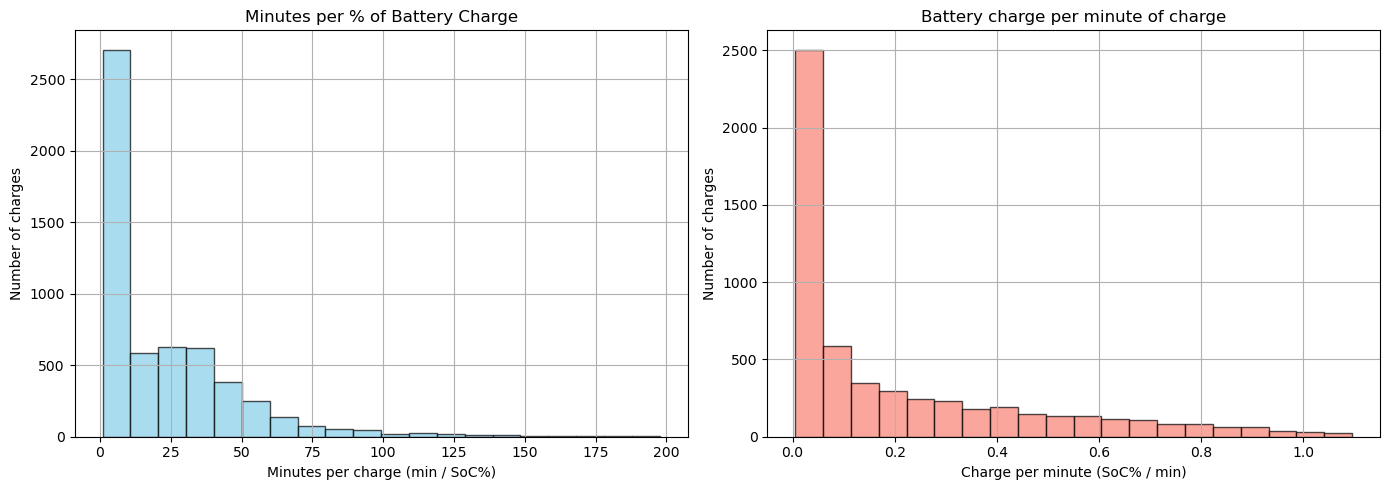

In [88]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Minutes per % battery
axes[0].hist(
    charge_data['min_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Minutes per % of Battery Charge')
axes[0].set_xlabel('Minutes per charge (min / SoC%)')
axes[0].set_ylabel('Number of charges')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    charge_data['charge_per_min'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery charge per minute of charge')
axes[1].set_xlabel('Charge per minute (SoC% / min)')
axes[1].set_ylabel('Number of charges')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [89]:
charge_data.head()

,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min
0,1,3,49.695429,81.940249,6.253198,31.555129,0,31.555129,2.596733,0.385099
1,1,3,56.084966,45.313458,2.898617,18.686957,1,18.686957,2.424871,0.412393
2,1,3,69.264511,42.108727,1.861403,8.333952,4,8.333952,5.052672,0.197915
3,1,3,56.014471,63.574237,6.286642,21.304951,10,21.304951,2.984012,0.335119
4,1,3,54.334593,44.342924,3.138045,33.974396,11,33.974396,1.305187,0.766174


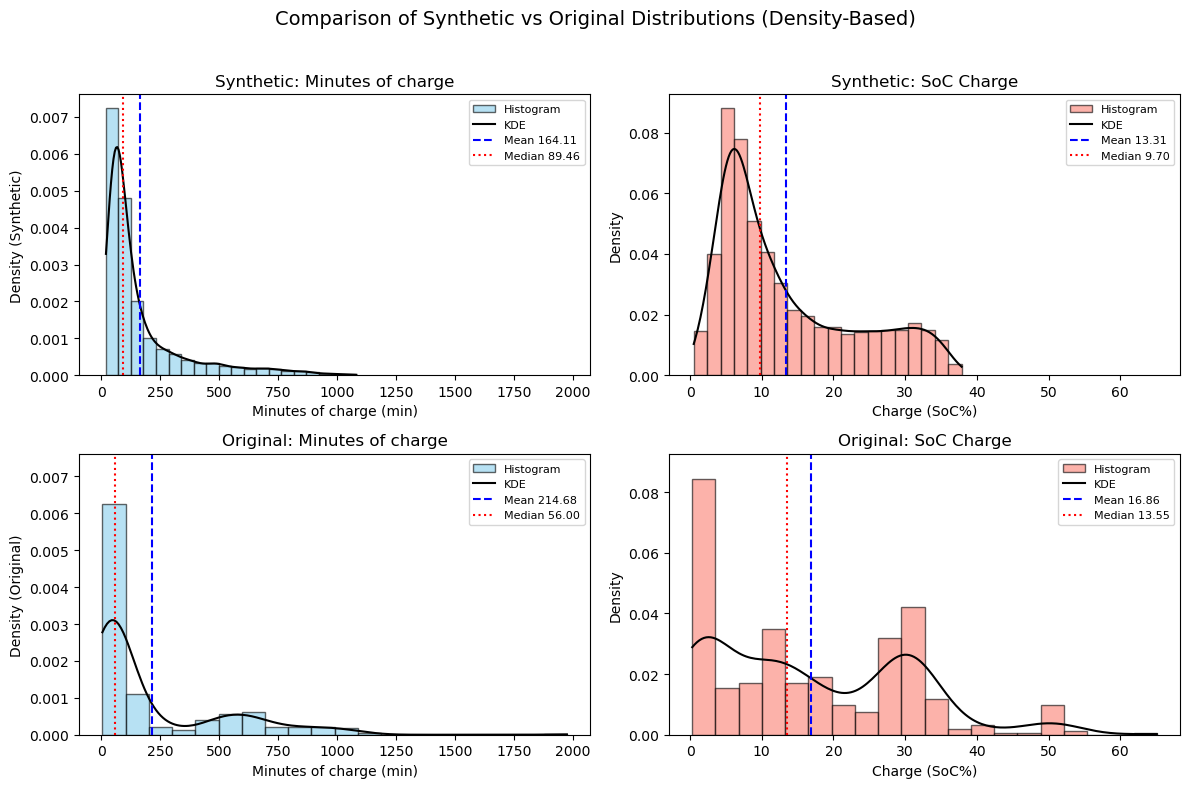

In [90]:
# --- Create figure with 2 rows (synthetic on top, original on bottom) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='col')

# Synthetic data (top row)
plot_hist_with_kde(charge_data.get('duration_minutes', pd.Series(dtype=float)), axes[0, 0],
                   color='skyblue', title='Synthetic: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data.get('charge', pd.Series(dtype=float)), axes[0, 1],
                   color='salmon', title='Synthetic: SoC Charge', xlabel='Charge (SoC%)')

# Original data (bottom row)
plot_hist_with_kde(charge_data_original.get('duration_minutes', pd.Series(dtype=float)), axes[1, 0],
                   color='skyblue', title='Original: Minutes of charge', xlabel='Minutes of charge (min)')

plot_hist_with_kde(charge_data_original.get('charge', pd.Series(dtype=float)), axes[1, 1],
                   color='salmon', title='Original: SoC Charge', xlabel='Charge (SoC%)')

# --- Match axes scales explicitly between synthetic and original ---
for j in range(2):
    xmin = min(axes[0, j].get_xlim()[0], axes[1, j].get_xlim()[0])
    xmax = max(axes[0, j].get_xlim()[1], axes[1, j].get_xlim()[1])
    ymin = min(axes[0, j].get_ylim()[0], axes[1, j].get_ylim()[0])
    ymax = max(axes[0, j].get_ylim()[1], axes[1, j].get_ylim()[1])
    axes[0, j].set_xlim(xmin, xmax)
    axes[1, j].set_xlim(xmin, xmax)
    axes[0, j].set_ylim(ymin, ymax)
    axes[1, j].set_ylim(ymin, ymax)

# --- Show x-axis tick labels for top plots too ---
for ax in axes[0, :]:
    ax.tick_params(labelbottom=True)

# --- Formatting ---
axes[0, 0].set_ylabel("Density (Synthetic)")
axes[1, 0].set_ylabel("Density (Original)")
fig.suptitle("Comparison of Synthetic vs Original Distributions (Density-Based)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

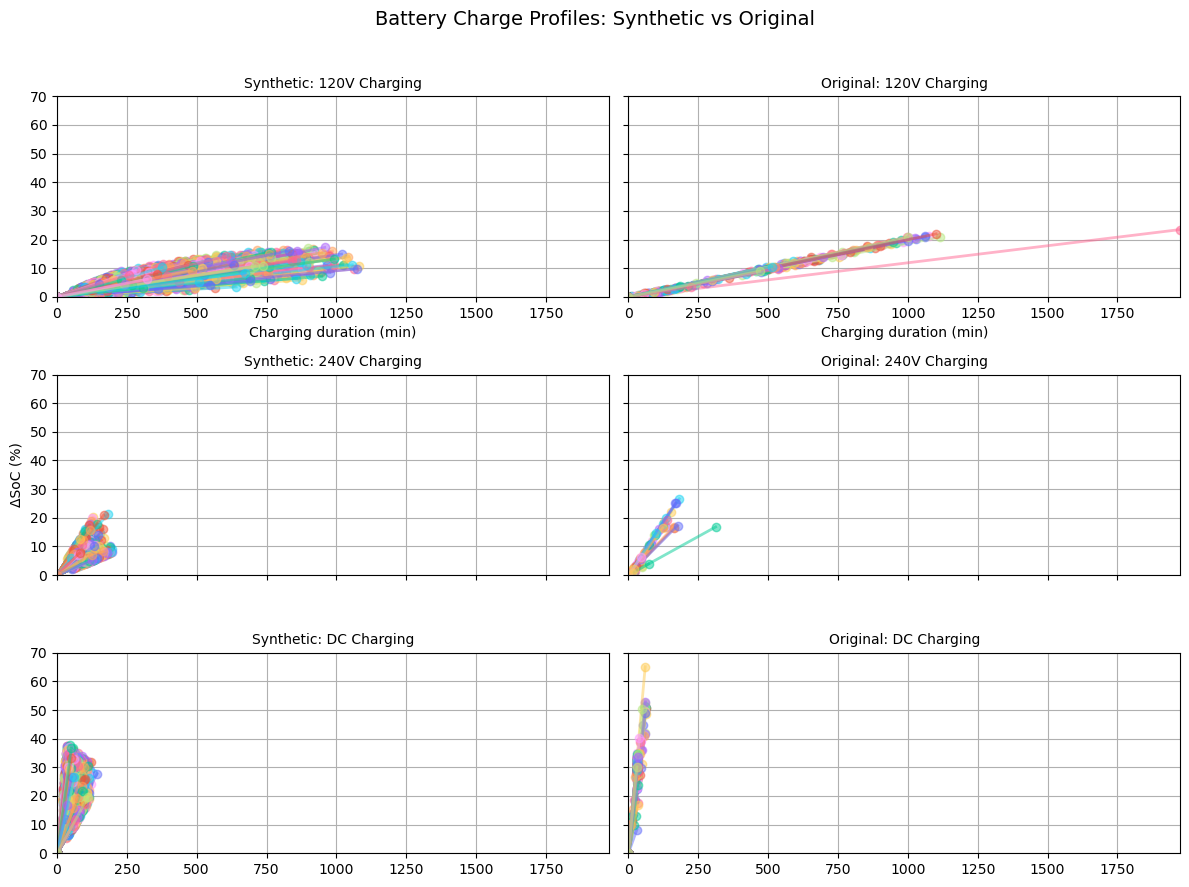

In [91]:
# --- Synthetic data prep ---
charge_data = charge_data.copy()
charge_data['delta_soc'] = charge_data['charge']  # already ΔSoC
charge_data['soc'] = 0
charge_data['end_soc'] = charge_data['delta_soc']

# --- Original data prep ---
charge_data_original = charge_data_original.copy()
charge_data_original['delta_soc'] = (
    charge_data_original['end_soc'] - charge_data_original['soc']
)
charge_data_original['soc'] = 0
charge_data_original['end_soc'] = charge_data_original['delta_soc']

# --- Shared scales ---
max_minutes = max(
    charge_data['duration_minutes'].max(),
    charge_data_original['duration_minutes'].max()
)
max_soc = 70  # y-limit

# --- Colors ---
colors = px.colors.qualitative.Plotly
n_colors = len(colors)

# --- Mode mapping ---
mode_titles = {
    '120': ('Synthetic: 120V Charging', 'Original: 120V Charging'),
    '240': ('Synthetic: 240V Charging', 'Original: 240V Charging'),
    'DC':  ('Synthetic: DC Charging', 'Original: DC Charging')
}

# --- Figure setup ---
fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(12, 9),
    sharex=True, sharey=True
)

# --- Loop through modes ---
for i, (key, (title_syn, title_orig)) in enumerate(mode_titles.items()):

    # --- Filter synthetic (numeric codes) ---
    if key == 'DC':
        syn = charge_data[charge_data['charge_mode'] == 3]
    elif key == '120':
        syn = charge_data[charge_data['charge_mode'] == 1]
    elif key == '240':
        syn = charge_data[charge_data['charge_mode'] == 2]

    # --- Filter original (string-based modes) ---
    if key == 'DC':
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
        ]
    else:
        orig = charge_data_original[
            charge_data_original['charge_mode'].astype(str).str.contains(key, case=False, na=False)
        ]

    # --- LEFT: Synthetic ---
    ax_syn = axes[i, 0]
    for j, (_, row) in enumerate(syn.iterrows()):
        ax_syn.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_syn.set_title(title_syn, fontsize=10)
    ax_syn.grid(True)
    ax_syn.set_xlim(0, max_minutes)
    ax_syn.set_ylim(0, max_soc)
    if i == 1:
        ax_syn.set_ylabel("ΔSoC (%)")

    # --- RIGHT: Original ---
    ax_orig = axes[i, 1]
    for j, (_, row) in enumerate(orig.iterrows()):
        ax_orig.plot(
            [0, row['duration_minutes']],
            [0, row['end_soc']],  # always start from 0
            marker='o',
            alpha=0.5,
            color=colors[j % n_colors],
            linewidth=2
        )
    ax_orig.set_title(title_orig, fontsize=10)
    ax_orig.grid(True)
    ax_orig.set_xlim(0, max_minutes)
    ax_orig.set_ylim(0, max_soc)

# --- Shared ----
for ax in axes[0, :]:
    ax.set_xlabel("Charging duration (min)")
    ax.tick_params(labelbottom=True)

fig.suptitle("Battery Charge Profiles: Synthetic vs Original", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [92]:
charge_data.head()

,event,charge_mode,duration_b_e,duration_minutes,km_driven,charge,id,delta_soc,min_per_perc_of_battery,charge_per_min,soc,end_soc
0,1,3,49.695429,81.940249,6.253198,31.555129,0,31.555129,2.596733,0.385099,0,31.555129
1,1,3,56.084966,45.313458,2.898617,18.686957,1,18.686957,2.424871,0.412393,0,18.686957
2,1,3,69.264511,42.108727,1.861403,8.333952,4,8.333952,5.052672,0.197915,0,8.333952
3,1,3,56.014471,63.574237,6.286642,21.304951,10,21.304951,2.984012,0.335119,0,21.304951
4,1,3,54.334593,44.342924,3.138045,33.974396,11,33.974396,1.305187,0.766174,0,33.974396


In [93]:
charge_data['charge_per_min'].describe()

count    5602.000000
mean        0.213497
std         0.254010
min         0.005060
25%         0.029059
50%         0.082306
75%         0.331385
max         1.095350
Name: charge_per_min, dtype: float64

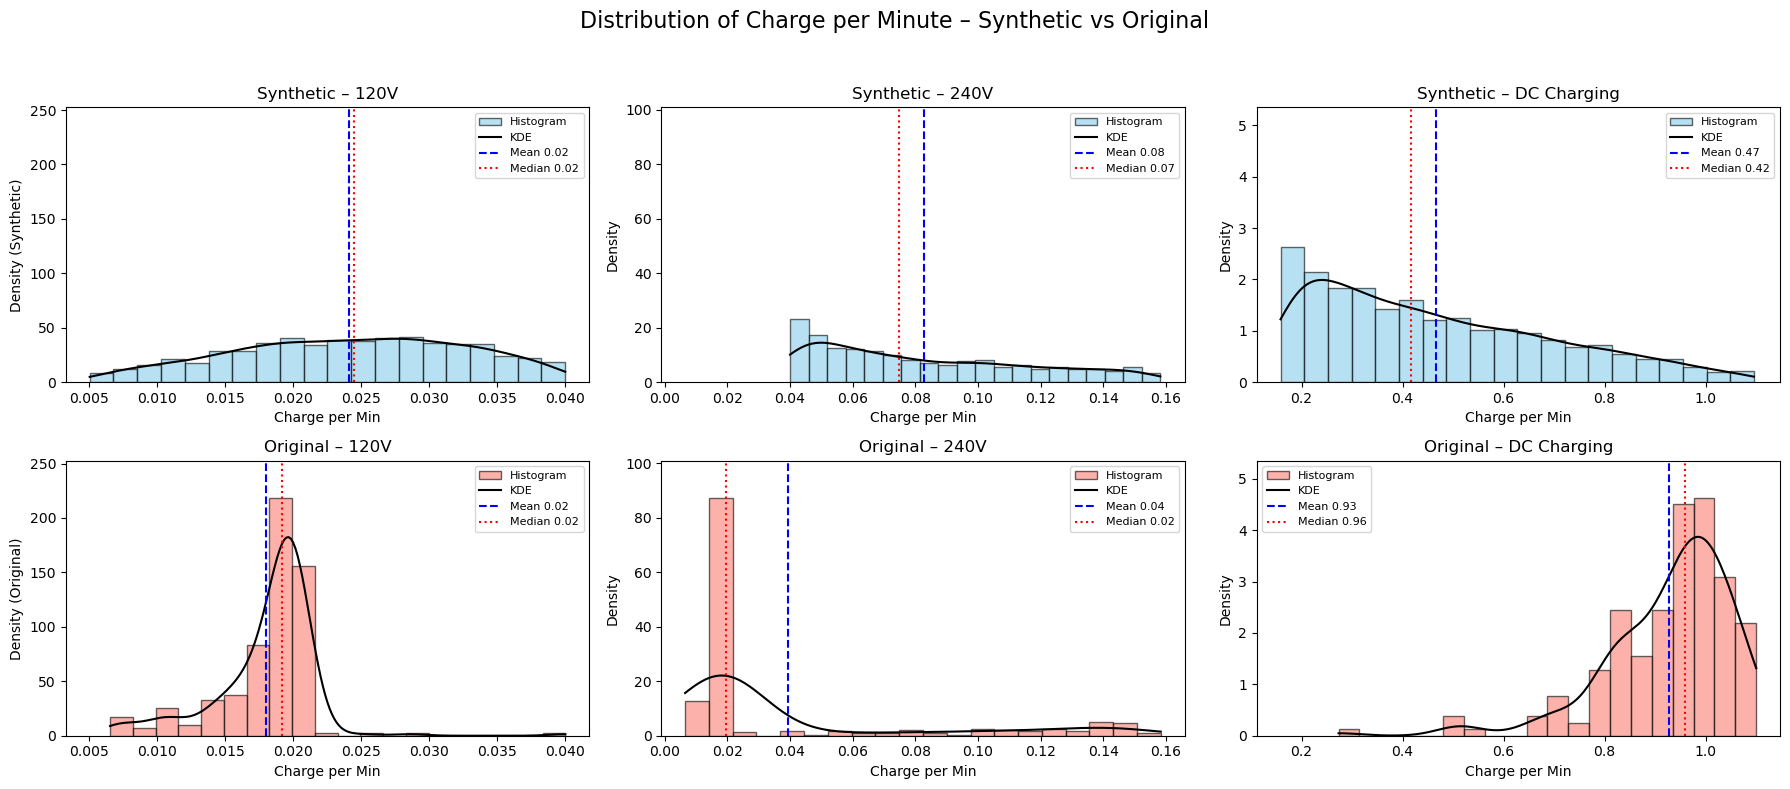

In [94]:
# --- Distribution of Charge per Min: Synthetic vs Original ---

# Map charge_mode values to labels
charge_labels = {1: "120V", 2: "240V", 3: "DC Charging"}

# Figure setup: 2 rows (synthetic/original) × 3 columns (charge modes)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))  # no sharex or sharey now

for i, mode in enumerate([1, 2, 3]):
    # --- Synthetic ---
    data_syn = charge_data.loc[charge_data['charge_mode'] == mode, 'charge_per_min']
    ax_syn = axes[0, i]
    plot_hist_with_kde(
        data_syn,
        ax=ax_syn,
        color='skyblue',
        title=f"Synthetic – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Original ---
    if mode == 3:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains('DC', case=False, na=False)
    else:
        mask_orig = charge_data_original['charge_mode'].astype(str).str.contains(str(mode), case=False, na=False)
    data_orig = charge_data_original.loc[mask_orig, 'charge_per_min']

    ax_orig = axes[1, i]
    plot_hist_with_kde(
        data_orig,
        ax=ax_orig,
        color='salmon',
        title=f"Original – {charge_labels[mode]}",
        xlabel='Charge per Min'
    )

    # --- Smart x-axis per column ---
    all_data = pd.concat([data_syn, data_orig]).dropna()
    if not all_data.empty:
        xmin, xmax = all_data.min(), all_data.max()
        xmargin = (xmax - xmin) * 0.05
        ax_syn.set_xlim(xmin - xmargin, xmax + xmargin)
        ax_orig.set_xlim(xmin - xmargin, xmax + xmargin)

    # --- Smart y-axis per column ---
    ymax_vals = [ax_syn.get_ylim()[1], ax_orig.get_ylim()[1]]
    ymax = max(ymax_vals) * 1.1  # 10% padding
    ax_syn.set_ylim(0, ymax)
    ax_orig.set_ylim(0, ymax)

# --- Common labels ---
axes[0, 0].set_ylabel('Density (Synthetic)')
axes[1, 0].set_ylabel('Density (Original)')

fig.suptitle("Distribution of Charge per Minute – Synthetic vs Original", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

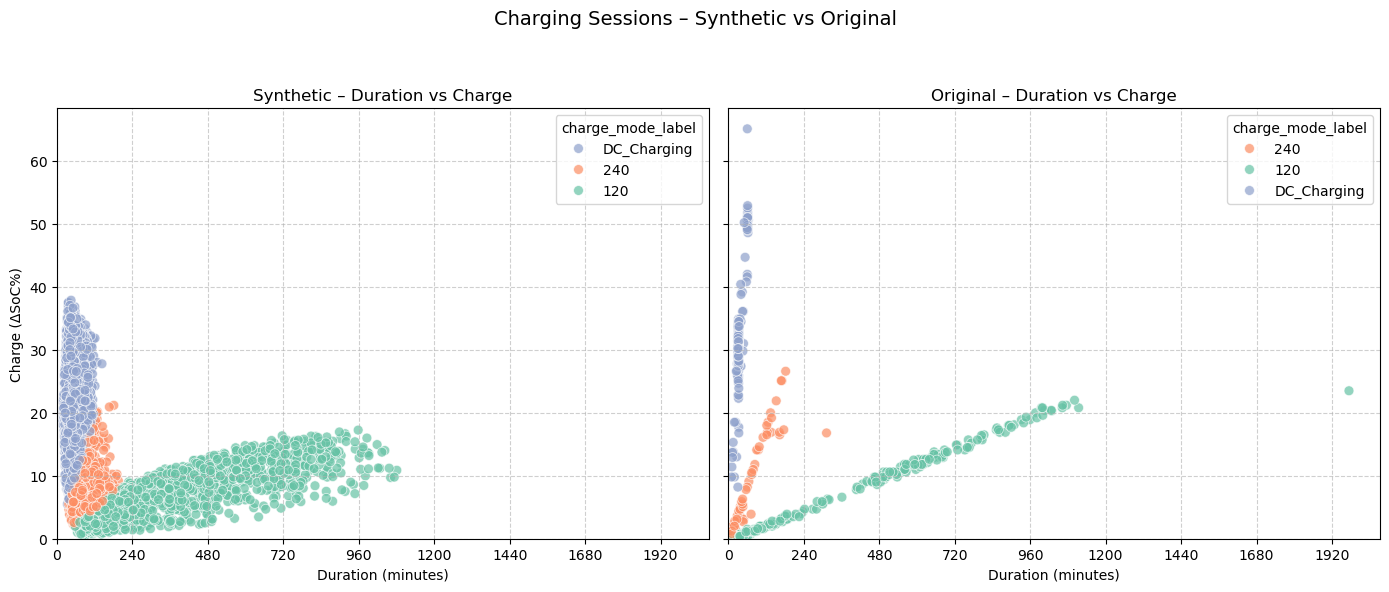

In [95]:
# --- Copy to avoid modifying originals ---
charge_data_syn = charge_data.copy()
charge_data_orig = charge_data_original.copy()

# --- Normalize charge_mode labels for consistency ---
def normalize_label_syn(val):
    if val == 1:
        return '120'
    elif val == 2:
        return '240'
    elif val == 3:
        return 'DC_Charging'
    else:
        return None

def normalize_label_orig(val):
    s = str(val).strip().lower()
    if 'dc' in s:
        return 'DC_Charging'
    elif '120' in s:
        return '120'
    elif '240' in s:
        return '240'
    else:
        return None

charge_data_syn['charge_mode_label'] = charge_data_syn['charge_mode'].apply(normalize_label_syn)
charge_data_orig['charge_mode_label'] = charge_data_orig['charge_mode'].apply(normalize_label_orig)

# --- Define consistent color palette ---
fixed_palette = {
    "120": "#66c2a5",        # greenish
    "240": "#fc8d62",        # orange
    "DC_Charging": "#8da0cb" # blue
}

# --- Shared axis limits for fair comparison ---
max_duration = max(
    charge_data_syn['duration_minutes'].max(),
    charge_data_orig['duration_minutes'].max()
)
max_charge = max(
    charge_data_syn['charge'].max(),
    charge_data_orig['charge'].max()
)

# --- Create side-by-side subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# ==========================================================
# LEFT: Synthetic
# ==========================================================
sns.scatterplot(
    data=charge_data_syn,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("Synthetic – Duration vs Charge", fontsize=12)
axes[0].set_xlim(0, max_duration * 1.05)
axes[0].set_ylim(0, max_charge * 1.05)
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Charge (ΔSoC%)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(60))

# ==========================================================
# RIGHT: Original
# ==========================================================
sns.scatterplot(
    data=charge_data_orig,
    x='duration_minutes',
    y='charge',
    hue='charge_mode_label',
    palette=fixed_palette,
    s=50,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("Original – Duration vs Charge", fontsize=12)
axes[1].set_xlim(0, max_duration * 1.05)
axes[1].set_ylim(0, max_charge * 1.05)
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(240))



# --- Final layout ---
fig.suptitle("Charging Sessions – Synthetic vs Original", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [96]:
charge_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5602 entries, 0 to 5601
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event                    5602 non-null   int64  
 1   charge_mode              5602 non-null   int64  
 2   duration_b_e             5602 non-null   float64
 3   duration_minutes         5602 non-null   float64
 4   km_driven                5602 non-null   float64
 5   charge                   5602 non-null   float64
 6   id                       5602 non-null   int64  
 7   delta_soc                5602 non-null   float64
 8   min_per_perc_of_battery  5602 non-null   float64
 9   charge_per_min           5602 non-null   float64
 10  soc                      5602 non-null   int64  
 11  end_soc                  5602 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 525.3 KB


### Save charge data cleaned

In [97]:
if SAVE:
    # Save DataFrame
    charge_data.to_csv(file_charge_path_csv, index=False)

# Save cleaned dataset

In [98]:
if SAVE:
    # Take raw generated data
    data = synthetic_data.copy()
    
    # load also trip_data and charge_data and then filter data, keeping only rows present in trip_data and charge_data
    
    trip_data_cleaned = pd.read_csv(file_trip_path_csv) 
    
    #take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
    trip_data_cleaned = trip_data_cleaned[['id']]
    charge_data_cleaned = pd.read_csv(file_charge_path_csv)
    
    # take only 'odo', 'end_odo', 'soc', 'end_soc', 'event', 'charge_mode','duration_minutes'
    charge_data_cleaned = charge_data_cleaned[[ 'id']]
    
    
    # keep rows that are present in ids of trip_data and charge_data
    data['id'] = data.index
    
    data = data[data['id'].isin(trip_data_cleaned['id']) | data['id'].isin(charge_data_cleaned['id'])]
    
    #drop columns 'id'
    data = data.drop(columns=['id'])
    
    #when event = 1 --> set end_odo = odo 
    #data.loc[data['event'] == 1, 'end_odo'] = data['odo']
    data.loc[data['event'] == 1, 'km_driven'] = 0
    
    # add in first position column 'vin', all rows with value -2.47174E+18 (vin2) or -1.12313E+18 (vin3)
    #data.insert(0, 'vin', -2.47174E+18)
    
    # map event 0 -> trip, 1 -> charge
    data['event'] = data['event'].map({0: 'trip', 1: 'charge'})
    
    # map charge_mode 1 -> 120, 2 -> 240, 3 -> DC Charging
    data['charge_mode'] = data['charge_mode'].map({0: 0, 1: 120, 2: 240, 3: 'DC Charging'})
    data.to_csv(file_cleaned_path_csv, index=False)

In [99]:
print(f'Retained {len(trip_data)} / {len(synthetic_data[synthetic_data['event'] == 0])} trip events')
print(f'Retained {len(charge_data)} / {len(synthetic_data[synthetic_data['event'] == 1])} charge events')
print(f'In summary the cleaned dataset is composed by {len(trip_data) + len(charge_data)} events, corresponding to {(len(trip_data) + len(charge_data)) * 100 / (len(synthetic_data[synthetic_data['event'] == 0]) + len(synthetic_data[synthetic_data['event'] == 1])):.2f}% of retained synthetic data.')

Retained 9148 / 11571 trip events
Retained 5602 / 5839 charge events
In summary the cleaned dataset is composed by 14750 events, corresponding to 84.72% of retained synthetic data.
